Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7fcee650fba0>
  [1] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7fcee6adccc0>
  [2] Plot1_ttbar -> Plotting builder=<function plotting_1 at 0x7fcee607a980>
Edges:
  Fileset_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot1_ttbar

Run config:
  Strategy:  by_dataset
  Executor:  default (FuturesExecutor)
  Facility:  local

Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7fcee650fba0> and user parameters None
processes in fileset: ['ttbar__nominal', 'ttbar__scaledown', 'ttbar__scaleup', 'ttbar__ME_var', 'ttbar__PS_var', 'single_top_s_chan__nominal', 'single_top_t_chan__nominal', 'single_top_tW__nominal', 'wjets__nominal']

example of information in fileset:
{
  'files': [https://xrootd-local.unl.edu:1094//store/user/AGC/nanoAOD/TT_TuneCUETP8M1_13TeV-powheg-pythia8/cmsopendata2015_ttbar_19980_PU25nsData2015v1_76X_mcRun2_asymptotic_v12_ext3-v1_0

Output()

Output()


execution took 5.54 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_1.json


Output()

...

Output()


execution took 13.67 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_11.json


Output()

Output()


execution took 14.20 seconds
Successfully processed!
  -> materialized at cache/Analysis/06e92cb87ee31abf2273ae1b9985f0a009d236a931581addc8bc701c23fee65f

Executing step 'Plot1_ttbar' of type 'Plotting' with the user code <function plotting_1 at 0x7fcee607a980> and user parameters None
dict_keys(['builder', 'n_chunks_total', 'n_chunks_ok', 'failures', 'processor_result'])
  -> materialized at cache/Plotting/5562ec90122989fb5d662a1ea5832f5d0475b3a0a6d4dd7f0fd4cd6e0a85822a


=== Run Summary ===
  ✓  Fileset_ttbar                  Fileset
  ✓  Analysis_ttbar                 Analysis             4/4 chunks OK
  ✓  Plot1_ttbar                    Plotting



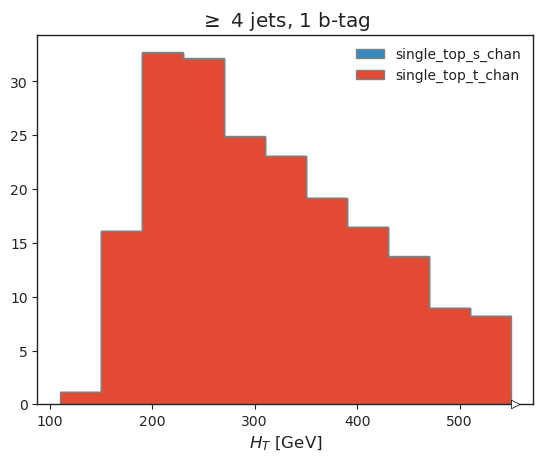

In [1]:
from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, run, ExecutorConfig
from coffea_workflow import facilities
from ttbar_analysis import get_fileset, run_analysis, plotting_1

step_fileset = Step(
							        name="Fileset_ttbar",
							        step_type = Fileset,
							        builder = get_fileset
							    )
step_analysis = Step(
						        name="Analysis_ttbar",
						        step_type = Analysis,
						        builder = run_analysis,
						    )

step_plot1 = Step(
						        name="Plot1_ttbar",
						        step_type = Plotting,
						        builder = plotting_1,
						    )

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plot1, depends_on=[step_analysis])
config = RunConfig(percentage=10, strategy="by_dataset", cache_dir="cache", chunk_fraction=0.1)
result = run(workflow, config)

Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7fcee650fba0>
  [1] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7fcee6adccc0>
  [2] Plot1_ttbar -> Plotting builder=<function plotting_1 at 0x7fcee607a980>
Edges:
  Fileset_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot1_ttbar

Run config:
  Strategy:  by_dataset
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7fcee650fba0> and user parameters None
Extracted from cache: cache/Fileset/d5e015643db3c8fb273757aa2a7e4dc84bc2c41a854d7b340c24beff70986de0
  -> materialized at cache/Fileset/d5e015643db3c8fb273757aa2a7e4dc84bc2c41a854d7b340c24beff70986de0

Executing step 'Analysis_ttbar' of type 'Analysis' with the user code <function run_analysis at 0x7fcee6adccc0> and user parameters None
Extracted from cache: cache/Chunking/82ddd27ef0ab5083c3c845ddd95605ee9c2ca17fb673665271c32

Output()

Output()

Output()


execution took 72.59 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_13.json


...

Output()

Output()


execution took 38.44 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_16.json


Output()


execution took 39.58 seconds
Successfully processed!
  -> materialized at cache/Analysis/06e92cb87ee31abf2273ae1b9985f0a009d236a931581addc8bc701c23fee65f

Executing step 'Plot1_ttbar' of type 'Plotting' with the user code <function plotting_1 at 0x7fcee607a980> and user parameters None
dict_keys(['builder', 'n_chunks_total', 'n_chunks_ok', 'failures', 'processor_result'])
  -> materialized at cache/Plotting/5562ec90122989fb5d662a1ea5832f5d0475b3a0a6d4dd7f0fd4cd6e0a85822a


=== Run Summary ===
  ✓  Fileset_ttbar                  Fileset
  ✓  Analysis_ttbar                 Analysis             9/9 chunks OK
  ✓  Plot1_ttbar                    Plotting



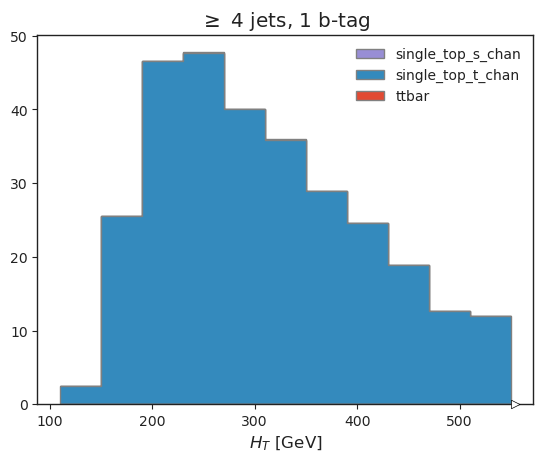

In [2]:
facility = facilities.CoffeaCasaFactory(
    worker_packages=("coffea>=2026.7.0",),
    worker_files=("ttbar_analysis.py", "utils"),
)
config = RunConfig(
    percentage=10, 
    strategy="by_dataset", 
    cache_dir="cache", 
    chunk_fraction=0.2,
    facility=facility,
    executor_config=ExecutorConfig(executor_type="DaskExecutor"),
)
result = run(workflow, config)